# 03 - Time Window Study

In [4]:
!pip install pymongo catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00


In [5]:
import os
import json
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from IPython.display import display
from pymongo import MongoClient
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
import tensorflow as tf

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "src").exists():
    ROOT = ROOT.parent

load_dotenv(str(ROOT / ".env"), override=False)

def load_colab_secrets(keys: list[str]) -> None:
    try:
        from google.colab import userdata
    except Exception:
        return
    for key in keys:
        if os.getenv(key):
            continue
        try:
            value = userdata.get(key)
        except Exception:
            value = None
        if value:
            os.environ[key] = value

load_colab_secrets(["MONGO_URI", "MONGO_DB_NAME"])

sns.set_theme(style="whitegrid")

@dataclass
class ModelConfig:
    name: str
    type: str
    params: dict


MODEL_CONFIGS = [
    ModelConfig(name="catboost", type="cat", params={"iterations": 400, "learning_rate": 0.05, "depth": 6}),
]

TOP_FEATURES = [
    "wind_speed_10m_rolling_std_168h",
    "hour_sin",
    "is_day",
    "hour_of_day",
    "solar_radiation_category",
    "european_aqi_rolling_std_168h",
    "day_of_week_cos",
    "hour_cos",
    "european_aqi_rolling_std_24h",
    "european_aqi_rolling_min_168h",
    "pm10_rolling_mean_24h",
    "hour_traffic_weight",
    "days_since_last_rain",
    "relative_humidity_2m_rolling_min_24h",
    "pm10_rolling_mean_48h",
    "european_aqi_rolling_std_48h",
    "day_of_week",
    "pm10_rolling_mean_12h",
    "pm10_rolling_std_168h",
    "european_aqi_rolling_mean_3h",
    "day_of_week_sin",
    "european_aqi_rolling_min_3h",
    "pm2_5_rolling_mean_6h",
    "precipitation_cumulative_72h",
    "nitrogen_dioxide_lag_6h",
    "pm10_rolling_std_24h",
    "pm2_5_rolling_min_3h",
    "is_evening_rush",
    "pm2_5_rolling_min_6h",
    "pm2_5_rolling_mean_12h",
    "oxidant_index",
    "european_aqi_rolling_std_12h",
    "pressure_change_6h",
    "nitrogen_dioxide_lag_1h",
    "pm2_5_rolling_mean_3h",
    "pm10_rolling_min_3h",
    "relative_humidity_2m_rolling_std_24h",
    "weekend_traffic_factor",
    "european_aqi_lag_1h",
    "wind_speed_10m_rolling_min_48h",
]

ARTIFACTS_DIR = ROOT / "debug_exports"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

HORIZON = 72
SPLIT_RATIO = 0.9
TARGET_MODEL_COUNT = 10
MAX_DL_MODELS = 2
DL_TYPES = {"gru", "lstm"}

def get_mongo_client() -> MongoClient:
    uri = os.getenv("MONGO_URI")
    if not uri:
        raise ValueError("MONGO_URI is required")
    return MongoClient(uri)


def get_database():
    client = get_mongo_client()
    db_name = os.getenv("MONGO_DB_NAME", "aqi_predictor")
    return client.get_database(db_name)


def evaluate_forecast(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"rmse": rmse, "mae": mae, "r2": r2}


def per_horizon_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    metrics = {}
    horizons = y_true.shape[1]
    for idx in [23, 47, 71]:
        if idx < horizons:
            metrics[f"rmse_{idx+1}h"] = float(np.sqrt(mean_squared_error(y_true[:, idx], y_pred[:, idx])))
    return metrics


def _build_dl_model(model_type: str, input_shape: Tuple[int, int], output_steps: int, units: int):
    model = tf.keras.Sequential()
    if model_type == "gru":
        model.add(tf.keras.layers.GRU(units, input_shape=input_shape, return_sequences=False))
    else:
        model.add(tf.keras.layers.LSTM(units, input_shape=input_shape, return_sequences=False))
    model.add(tf.keras.layers.Dense(128, activation="relu"))
    model.add(tf.keras.layers.Dense(output_steps))
    model.compile(optimizer="adam", loss="mse")
    return model


def _prepare_sequence_data(
    features: pd.DataFrame, target: pd.Series, lookback: int, horizon: int
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    X, y, start_indices = [], [], []
    values = features.values
    target_values = target.values
    for idx in range(lookback, len(features) - horizon):
        X.append(values[idx - lookback : idx])
        y.append(target_values[idx : idx + horizon])
        start_indices.append(idx)
    return np.array(X), np.array(y), np.array(start_indices)


def train_model(
    config: ModelConfig,
    x_train: pd.DataFrame,
    y_train: pd.DataFrame,
    x_val: pd.DataFrame,
    y_val: pd.DataFrame,
    horizon: int = 72,
    feature_frame: pd.DataFrame = None,
    target: pd.Series = None,
    split_index: int = None,
) -> Tuple[object, np.ndarray, np.ndarray]:
    if config.type in {"lgbm", "xgb", "cat", "rf", "extra", "gbr", "ridge", "linreg"}:
        if config.type == "lgbm":
            base = lgb.LGBMRegressor(**config.params)
        elif config.type == "xgb":
            base = xgb.XGBRegressor(**config.params)
        elif config.type == "cat":
            base = cb.CatBoostRegressor(**config.params, verbose=False)
        elif config.type == "rf":
            base = RandomForestRegressor(**config.params)
        elif config.type == "extra":
            base = ExtraTreesRegressor(**config.params)
        elif config.type == "ridge":
            base = Ridge(**config.params)
        elif config.type == "linreg":
            base = LinearRegression(**config.params)
        else:
            base = GradientBoostingRegressor(**config.params)

        if config.type in {"rf", "extra", "ridge", "linreg"}:
            model = base
            model.fit(x_train, y_train)
        else:
            model = MultiOutputRegressor(base)
            model.fit(x_train, y_train)
        preds = model.predict(x_val)
        return model, preds, y_val.values

    if feature_frame is None or target is None or split_index is None:
        raise ValueError("feature_frame, target, and split_index are required for DL models")

    lookback = 24
    X_seq, y_seq, start_indices = _prepare_sequence_data(feature_frame, target, lookback, horizon)
    train_mask = start_indices + horizon <= split_index
    val_mask = start_indices >= split_index

    if not train_mask.any() or not val_mask.any():
        raise ValueError("Not enough sequences for the requested train/validation split")

    X_train, X_val = X_seq[train_mask], X_seq[val_mask]
    y_train, y_val = y_seq[train_mask], y_seq[val_mask]

    model = _build_dl_model(
        config.type, input_shape=(X_train.shape[1], X_train.shape[2]), output_steps=horizon, units=config.params.get("units", 64)
    )
    model.fit(
        X_train,
        y_train,
        epochs=config.params.get("epochs", 10),
        batch_size=config.params.get("batch_size", 32),
        verbose=0,
    )
    preds = model.predict(X_val)
    return model, preds, y_val


def select_models_from_configs(
    configs: list, target_count: int, max_dl_models: int
) -> list[str]:
    selected: list[str] = []
    dl_count = 0
    for config in configs:
        if config.type in DL_TYPES:
            if dl_count >= max_dl_models:
                continue
            dl_count += 1
        selected.append(config.name)
        if len(selected) >= target_count:
            break
    return selected


def select_shortlist_from_benchmark(
    bench_df: pd.DataFrame, target_count: int, max_dl_models: int
) -> list[str]:
    bench_df = bench_df.dropna(subset=["rmse"]).copy()
    if bench_df.empty:
        return []
    bench_df = bench_df.sort_values(["rmse", "model"], na_position="last")
    selected: list[str] = []
    dl_count = 0
    for _, row in bench_df.iterrows():
        model_name = str(row.get("model", "")).strip()
        if not model_name:
            continue
        model_type = str(row.get("type", "")).strip()
        if model_type in DL_TYPES:
            if dl_count >= max_dl_models:
                continue
            dl_count += 1
        selected.append(model_name)
        if len(selected) >= target_count:
            break
    return selected


def build_window_frame(frame: pd.DataFrame, days: int) -> pd.DataFrame:
    latest_timestamp = frame["timestamp"].max()
    window_start = latest_timestamp - pd.Timedelta(days=days)
    return frame.loc[frame["timestamp"] >= window_start].sort_values("timestamp").reset_index(drop=True)


def prepare_training_matrices(feature_frame: pd.DataFrame, target: pd.Series, split_index: int):
    if feature_frame.empty or len(feature_frame) <= HORIZON:
        return None, None, None, None, None

    max_start = len(target) - HORIZON
    if max_start <= 0 or split_index <= HORIZON or split_index >= max_start:
        return None, None, None, None, None

    x = feature_frame.iloc[:max_start].copy()
    y = pd.DataFrame([target.iloc[i : i + HORIZON].values for i in range(max_start)], index=x.index)
    start_indices = np.arange(max_start)

    train_mask = start_indices + HORIZON <= split_index
    val_mask = start_indices >= split_index

    if not train_mask.any() or not val_mask.any():
        return None, None, None, None, None

    return x.iloc[train_mask], y.iloc[train_mask], x.iloc[val_mask], y.iloc[val_mask], list(x.columns)


db = get_database()
collection = db["aqi_features_rawalpindi"]
data = pd.DataFrame(list(collection.find()))

if data.empty:
    raise ValueError("aqi_features_rawalpindi is empty")

if "_id" in data.columns:
    data = data.drop(columns=["_id"])

data["timestamp"] = pd.to_datetime(data["timestamp"], utc=True, errors="coerce")
data = data.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

feature_cols_all = [column for column in data.columns if column != "timestamp"]
feature_cols = [feature for feature in TOP_FEATURES if feature in data.columns] or feature_cols_all

try:
    bench_path = ARTIFACTS_DIR / "model_benchmark_metrics.csv"
    if bench_path.exists():
        bench_df = pd.read_csv(bench_path)
        shortlist_models = select_shortlist_from_benchmark(
            bench_df, TARGET_MODEL_COUNT, MAX_DL_MODELS
        )
    else:
        shortlist_models = select_models_from_configs(
            MODEL_CONFIGS, TARGET_MODEL_COUNT, MAX_DL_MODELS
        )
    if not shortlist_models:
        shortlist_models = select_models_from_configs(
            MODEL_CONFIGS, TARGET_MODEL_COUNT, MAX_DL_MODELS
        )
except Exception:
    shortlist_models = select_models_from_configs(
        MODEL_CONFIGS, TARGET_MODEL_COUNT, MAX_DL_MODELS
    )

window_days_list = [7, 30, 60, 90, 180, 365]
horizon = HORIZON

In [6]:
results = []
for days in window_days_list:
    window_frame = build_window_frame(data, days)
    if len(window_frame) < horizon + 200:
        results.append({"window_days": days, "rows": len(window_frame), "note": "insufficient_rows"})
        continue

    split_index = int(len(window_frame) * SPLIT_RATIO)
    if split_index <= horizon:
        results.append({"window_days": days, "rows": len(window_frame), "note": "split_too_small"})
        continue

    target = window_frame["european_aqi"].astype(float)
    feature_frame = window_frame[feature_cols].apply(pd.to_numeric, errors="coerce").ffill().fillna(0.0)
    feature_frame = feature_frame.loc[:, feature_frame.nunique(dropna=True) > 1].copy()

    x_train, y_train, x_val, y_val, used_features = prepare_training_matrices(feature_frame, target, split_index)
    if x_train is None or y_train is None or x_val is None or y_val is None:
        results.append({"window_days": days, "rows": len(window_frame), "note": "no_features_after_filter"})
        continue

    rows_after_prep = len(x_train) + len(x_val)

    # Iterate only over shortlisted best models (from benchmark) to evaluate per-window performance
    for model_name in shortlist_models:
        config = next((c for c in MODEL_CONFIGS if c.name == model_name), None)
        if config is None:
            results.append({"window_days": days, "model": model_name, "note": "config_not_found"})
            continue
        try:
            model, preds, y_true = train_model(
                config,
                x_train,
                y_train,
                x_val,
                y_val,
                horizon=horizon,
                feature_frame=feature_frame,
                target=target,
                split_index=split_index,
            )
            metrics = evaluate_forecast(y_true, preds)
            metrics.update(per_horizon_metrics(y_true, preds))
            results.append(
                {
                    "window_days": days,
                    "model": config.name,
                    "type": config.type,
                    "rows": len(window_frame),
                    "rows_after_prep": rows_after_prep,
                    "features_used": len(used_features),
                    **metrics,
                }
            )
        except Exception as exc:
            results.append(
                {
                    "window_days": days,
                    "model": config.name,
                    "type": config.type,
                    "rows": len(window_frame),
                    "rows_after_prep": rows_after_prep,
                    "features_used": len(used_features),
                    "error": str(exc),
                }
            )

results_df = pd.DataFrame(results)
if results_df.empty:
    raise ValueError("No model-window benchmark results were produced")

results_df = results_df.sort_values(["window_days", "rmse", "model"], na_position="last").reset_index(drop=True)
results_path = ARTIFACTS_DIR / "time_window_model_metrics.csv"
results_df.to_csv(results_path, index=False)

valid_results = results_df.dropna(subset=["rmse"]).copy()
if valid_results.empty:
    raise ValueError("All model-window benchmark runs failed")

window_summary = (
    valid_results.groupby("window_days")
    .agg(
        mean_rmse=("rmse", "mean"),
        median_rmse=("rmse", "median"),
        best_rmse=("rmse", "min"),
        best_model=("model", lambda series: series.iloc[0]),
        model_count=("model", "count"),
    )
    .reset_index()
)

best_window_row = window_summary.sort_values(["median_rmse", "mean_rmse"]).iloc[0]
best_window = int(best_window_row["window_days"])

with open(ARTIFACTS_DIR / "best_window_days.json", "w", encoding="utf-8") as handle:
    json.dump(
        {
            "best_window_days": best_window,
            "selection_metric": "median_rmse",
            "evaluated_windows": window_days_list,
        },
        handle,
        indent=2,
    )

display(results_df.head(30))
display(window_summary.sort_values("window_days"))

print(f"Saved {results_path}")
print(f"Best window: {best_window} days")

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


,window_days,rows,note,model,type,rows_after_prep,features_used,rmse,mae,r2,rmse_24h,rmse_48h,rmse_72h
0,7,169,insufficient_rows,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,30,721,NaN,catboost,cat,578.0,40.0,20.149788,13.314514,NaN,2.278648,27.937829,9.636595
2,60,1441,NaN,catboost,cat,1298.0,40.0,12.230721,8.380560,0.585456,6.209712,11.032770,22.038005
3,90,2161,NaN,catboost,cat,2018.0,40.0,10.552995,7.674244,0.601566,8.490971,10.356561,16.255597
4,180,4321,NaN,catboost,cat,4178.0,40.0,11.714939,8.186055,0.346387,10.108747,13.468135,16.251734
5,365,8761,NaN,catboost,cat,8618.0,40.0,12.619488,9.132506,0.429241,10.917203,14.323929,16.041428


,window_days,mean_rmse,median_rmse,best_rmse,best_model,model_count
0,30,20.149788,20.149788,20.149788,catboost,1
1,60,12.230721,12.230721,12.230721,catboost,1
2,90,10.552995,10.552995,10.552995,catboost,1
3,180,11.714939,11.714939,11.714939,catboost,1
4,365,12.619488,12.619488,12.619488,catboost,1


Saved /debug_exports/time_window_model_metrics.csv
Best window: 90 days


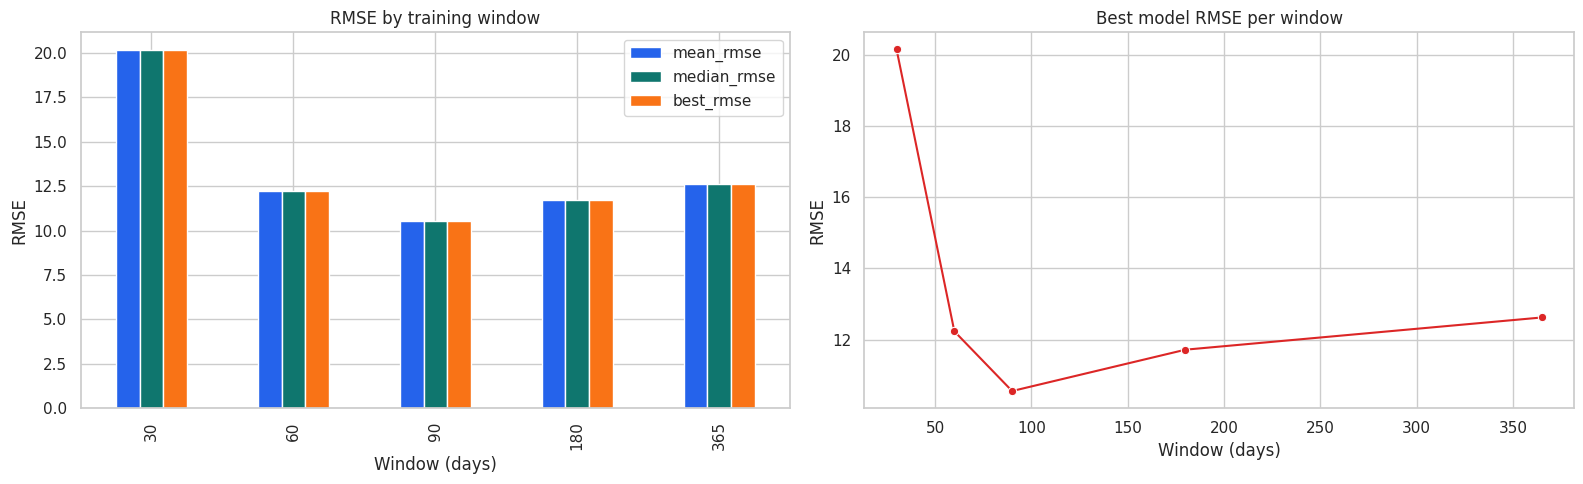

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

window_summary.sort_values("window_days").plot(
    x="window_days",
    y=["mean_rmse", "median_rmse", "best_rmse"],
    kind="bar",
    ax=axes[0],
    color=["#2563eb", "#0f766e", "#f97316"],
)
axes[0].set_title("RMSE by training window")
axes[0].set_xlabel("Window (days)")
axes[0].set_ylabel("RMSE")
axes[0].legend(loc="best")

best_by_window = valid_results.sort_values("rmse").groupby("window_days").first().reset_index()
sns.lineplot(data=best_by_window, x="window_days", y="rmse", marker="o", ax=axes[1], color="#dc2626")
axes[1].set_title("Best model RMSE per window")
axes[1].set_xlabel("Window (days)")
axes[1].set_ylabel("RMSE")

plt.tight_layout()

No hourly gaps detected in the loaded series.


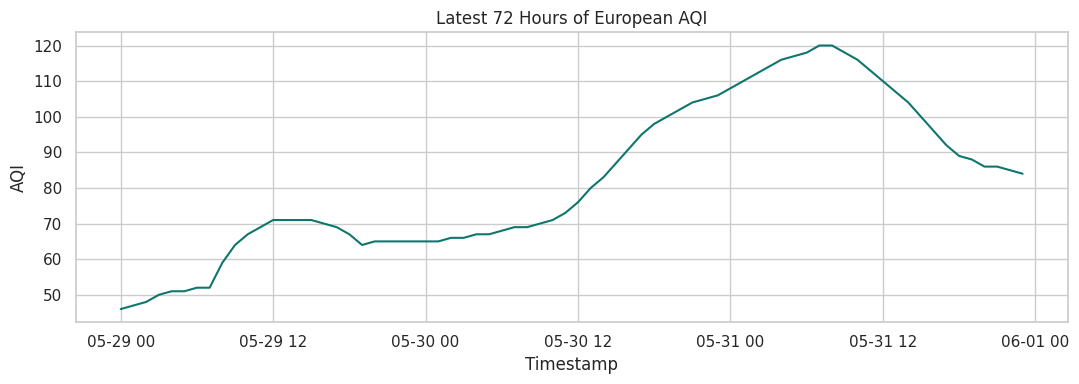

In [8]:
timestamp_diff_hours = data["timestamp"].diff().dt.total_seconds().div(3600)
gap_counts = timestamp_diff_hours[timestamp_diff_hours > 1].dropna().round().value_counts().sort_index()

if gap_counts.empty:
    print("No hourly gaps detected in the loaded series.")
else:
    display(gap_counts.to_frame(name="gap_count"))

recent_slice = data.tail(72).copy()
fig, ax = plt.subplots(figsize=(11, 4))
sns.lineplot(data=recent_slice, x="timestamp", y="european_aqi", ax=ax, color="#0f766e")
ax.set_title("Latest 72 Hours of European AQI")
ax.set_xlabel("Timestamp")
ax.set_ylabel("AQI")
plt.tight_layout()

In [9]:
selected_window_results = valid_results[valid_results["window_days"] == best_window].sort_values("rmse").reset_index(drop=True)
display(
    selected_window_results[
        ["window_days", "model", "type", "rmse", "mae", "r2", "rows_after_prep", "features_used"]
    ]
)

print(f"Best-window leaderboard is based on {best_window} days and has been saved to debug_exports.")

,window_days,model,type,rmse,mae,r2,rows_after_prep,features_used
0,90,catboost,cat,10.552995,7.674244,0.601566,2018.0,40.0


Best-window leaderboard is based on 90 days and has been saved to debug_exports.
